<a href="https://colab.research.google.com/github/silviasd2025-bit/dea_studies/blob/main/20260114_dea_dim_imp_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Jupiter DEA computes DEA VRS / CRS with configurable inputs/output

In [ ]:
import subprocess
subprocess.check_call(['pip', 'install', 'pulp'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

0

In [ ]:
from datetime import datetime
import os
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# The core DEA class, setting up and solving the linear programming
# problems using PuLP.



class DEAProblem:

    """
    A container for the elements of a data envelopment analysis problem. Sets
    up the linear programmes and solves them with pulp.

    Requires:

        inputs: a pandas dataframe of the inputs to the DMUs
        outputs: a pandas dataframe of the outputs from the DMUs
        kind: 'VRS' or 'CRS'
        in_weights: the weight restriction to apply to all inputs to all DMUs
                    (default is [0, inf])
        out_weights: the weight restriction to apply to all outputs to all DMUs
                     (default is [0, inf)

    Weight restrictions must be specified as a list. To specify only one bound
    leave the other as None, eg. in_weights=[1, None].

    """

    def __init__(self, inputs, outputs, returns='CRS',
                 in_weights=[0, None], out_weights=[0, None]):
        """
        Set up the DMUs' problems, ready to solve.

        """
        self.inputs = _to_dataframe(inputs)
        self.outputs = _to_dataframe(outputs)
        self.returns = returns

        self.J, self.I = self.inputs.shape  # no of firms, inputs
        _, self.R = self.outputs.shape  # no of outputs
        self._i = range(self.I)  # inputs
        self._r = range(self.R)  # outputs
        self._j = range(self.J)  # DMUs

        self._in_weights = in_weights  # input weight restrictions
        self._out_weights = out_weights  # output weight restrictions

        # creates dictionary of pulp.LpProblem objects for the DMUs
        self.dmus = self._create_problems()

    def _create_problems(self):
        """
        Iterate over the inputs and create a dictionary of LP problems, one
        for each DMU.

        """

        dmu_dict = {}
        for j0 in self._j:
            dmu_dict[j0] = self._make_problem(j0)
        return dmu_dict

    def _make_problem(self, j0):
        """
        Create a pulp.LpProblem for a DMU.

        """

        # Set up pulp
        prob = pulp.LpProblem("".join(["DMU_", str(j0)]), pulp.LpMaximize)
        self.inputWeights = pulp.LpVariable.dicts("inputWeight", (self._j, self._i),
                                                  lowBound=self._in_weights[0], upBound=self._in_weights[1])
        self.outputWeights = pulp.LpVariable.dicts("outputWeight", (self._j, self._r),
                                                   lowBound=self._out_weights[0], upBound=self._out_weights[1])

        # Set returns to scale
        if self.returns == "CRS":
            w = 0
        elif self.returns == "VRS":
            w = pulp.LpVariable.dicts("w", (self._j, self._r))
        else:
            raise Exception(ValueError)

        # Set up objective function
        prob += pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j0][r1]) for r1 in self._r]) - w

        # Set up constraints
        prob += pulp.LpAffineExpression([(self.inputWeights[j0][i1],
                                          self.inputs.values[j0][i1]) for i1 in self._i]) == 1, "Norm_constraint"
        for j1 in self._j:
            prob += self._dmu_constraint(j0, j1) - \
                w <= 0, "".join(["DMU_constraint_", str(j1)])
        return prob

    def _dmu_constraint(self, j0, j1):
        """
        Calculate and return the DMU constraint for a single DMU's LP problem.

        """

        eOut = pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j1][r1]) for r1 in self._r])
        eIn = pulp.LpAffineExpression(
            [(self.inputWeights[j0][i1], self.inputs.values[j1][i1]) for i1 in self._i])
        return eOut - eIn

    def _solver(self):
        """
        Iterate over the dictionary of DMUs' problems, solve them, and collate
        the results into a pandas dataframe.

        """

        sol_status = {}
        sol_weights = {}
        sol_efficiency = {}

        for ind, problem in list(self.dmus.items()):
            problem.solve()
            sol_status[ind] = pulp.LpStatus[problem.status]
            sol_weights[ind] = {}
            for v in problem.variables():
                sol_weights[ind][v.name] = v.varValue
            sol_efficiency[ind] = pulp.value(problem.objective)
        return sol_status, sol_efficiency, sol_weights

    def _build_weight_results_dict(self, sol_weights):
        """
        Rename weights from input and output column names, then build a
        pandas dataframe of all weights.

        """
        import re
        tmp_dict = {}
        for dmu, d in list(sol_weights.items()):
            tmp_dict[dmu] = {}
            for key, _ in list(d.items()):
                m = re.search(r'[0-9]+$',key)
                i = int(m.group(0))
                if key.startswith("input"):
                    tmp_dict[dmu]["in_" + str(self.inputs.columns[i])] = d[key]
                if key.startswith("output"):
                    tmp_dict[dmu][
                        "out_" + str(self.outputs.columns[i])] = d[key]
        weight_results = pd.DataFrame.from_dict(tmp_dict).T

        return weight_results

    def solve(self, sol_type='technical'):
        """"
        Solve the problem and create attributes to hold the solutions.

        Takes:
            sol_type: 'technical'/'allocative'/'economic'
            dmus: tuple defining range of DMUs to solve for.

        """

        if sol_type == 'technical':
            sol_status, sol_efficiency, sol_weights = self._solver()
            weight_results = self._build_weight_results_dict(sol_weights)
            status_df = pd.Series(sol_status, name='Status')
            status_df.index = self.inputs.index
            efficiency_df = pd.Series(sol_efficiency, name='Efficiency')
            efficiency_df.index = self.inputs.index

            return DEAResults((('Status', status_df),
                               ('Efficiency', efficiency_df),
                               ('Weights', weight_results)))
        else:
            print("Solution type not yet implemented.")
            print("Solving for technical efficiency instead.")
            self.solve()


class DEAResults(dict):

    """
    A class to hold the results of a DEAProblem and provide methods for
    their examination. Essentially a dictionary of pandas Series with
    methods for conducting particular operations on DEA results.

    """

#    def __init__(self):
#        super(DEAResults, self).__init__()
#        pass

    def find_comparators(self, dmu):
        """
        Return the DMUs that form the frontier for the specified DMU.

        """
        pass

    def env_corr(self, env_vars, qq_plot=False):
        """
        Determine correlations with environmental/non-discretionary variables
        using a logit regression. Tobit will be implemented when available
        upstream in statsmodels.

        Takes:
            env_vars: A pandas dataframe of environmental variables

        Returns:
            corr_mod: the statsmodels' model instance containing the inputs
                      and results from the logit model.

        Note that there can be no spaces in the variables' names.
        """

        import matplotlib.pyplot as plt
        from statsmodels.regression.linear_model import OLS
        from statsmodels.graphics.gofplots import qqplot

        env_data = _to_dataframe(env_vars)
        corr_data = env_data.join(self['Efficiency'])
        corr_mod = OLS.from_formula(
            "Efficiency ~ " + " + ".join(env_vars.columns), corr_data)
        corr_res = corr_mod.fit()

        #plot qq of residuals
        if qq_plot:
            qqplot(corr_res.resid, line='s')
            plt.title('Distribution of residuals')

        print(corr_res.summary())

        return corr_res


def _to_dataframe(indata):
    """
    Indexers require input to be a dataframe but the user may pass a
    series. Check and cast series to dataframes.

    """

    if type(indata) == pd.core.frame.DataFrame:
        return indata
    elif type(indata) == pd.core.series.Series:
        return pd.DataFrame(indata, columns=['input_data'])
    else:
        raise TypeError(
            "Input data is not a valid pandas DataFrame or Series.")


In [ ]:
def normalize_data(data):
    """
    Normalize data using robust scaling
    """

    # Calculate min and max values for each column
    min_vals = np.min(data, axis=0)

    max_vals = np.max(data, axis=0)
    range_vals = max_vals - min_vals

    # Replace 0 values with 1 to avoid division by zero DOES NOT WORK so commment 2026/01/21
    #range_vals[range_vals == 0] = 1

    # Scale to [0.1, 1] range
    normalized = 0.1 + 0.9 * (data - min_vals) / range_vals

    return normalized

In [ ]:
# DEA accepts : 'VRS' or 'CRS'

# Load data
df_read_old = pd.read_csv("/content/drive/MyDrive/data/20251202_owid-energy-dataDEAMPIEnergySecurityEvaluationG20.csv")
df_read_new = pd.read_csv("/content/drive/MyDrive/data/owid-energy-data G20.csv")


# Print the shape
print(df_read_new.shape)

df_new = df_read_new
df_old = df_read_old

# Remove last year from table so that data can be passed from one table to the other
df_new = df_new[df_new['year'] <= 2023]


print ("New table")
print ("==========")
print(df_new.shape)
print(df_new.columns.tolist())
list_of_variables_new_table = df_new.columns.tolist()
for elem in list_of_variables_new_table:
  print("variable(new table):", elem)

print ("Old table")
print ("==========")
print(df_old.shape)
print(df_old.columns.tolist())

list_of_variables_old_table = df_old.columns.tolist()
for elem in list_of_variables_old_table:
  print("variable(old table):", elem)

# Change name of columns 'dmu' is needed
df_new.rename(columns = {'country':'dmu'}, inplace = True)
df_old.rename(columns = {'country':'dmu'}, inplace = True)

# Replace dmu 'European Union'  by EU27
df_new['dmu'] = df_new['dmu'].replace('Europe', 'EU27')
df_old['dmu'] = df_old['dmu'].replace('Europe', 'EU27')

alpha_coal = 0.85
alpha_gas  = 0.90
alpha_oil  = 0.90
alpha_nuclear = 0.90
alpha_biofuel = 0.9
alpha_hydro = 0.75
alpha_solar = 0.25
alpha_wind_onshore = 0.20
alpha_wind_offshore =0.25
alpha_wind = 0.20


# Computations with columns

df_new['hhi'] = (df_new['biofuel_share_energy']**2 + df_new['coal_share_energy']**2 + df_new['gas_share_energy']**2\
             + df_new['hydro_share_energy']**2 + df_new['nuclear_share_energy']**2 + df_new['oil_share_energy']**2\
             + df_new['solar_share_energy']**2 + df_new['wind_share_energy']**2 + df_new['other_renewables_share_energy']**2)

df_new['inv_hhi'] = 1 / df_new['hhi']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)
df_new['gdp_per_capita'] = df_new['gdp'] / df_new['population']

df_new['net_elec_imports_positive'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)

df_new['net_elec_export'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_export'] = -df_new['net_elec_export'].where(df_new['net_elec_export'] <= 0, 0)

df_new['firm_capacity_factor'] = df_new['biofuel_elec_per_capita']/alpha_biofuel + df_new['coal_elec_per_capita']/alpha_coal\
    + df_new['gas_elec_per_capita'] / alpha_gas + df_new['hydro_elec_per_capita'] / alpha_hydro + df_new['nuclear_elec_per_capita']/alpha_nuclear\
     + df_new['oil_elec_per_capita']/ alpha_oil + df_new['solar_elec_per_capita']/ alpha_solar + df_new['wind_elec_per_capita']/  alpha_wind



df_old['net_elec_imports_positive'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_imports_positive'] = df_old['net_elec_imports_positive'].where(df_old['net_elec_imports_positive'] >= 0, 0)

df_old['net_elec_export'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_export'] = -df_old['net_elec_export'].where(df_old['net_elec_export'] <= 0, 0)

# Print the shape

print(df_new.shape)
countries = list(df_new['dmu'].unique())
years     = list(df_new['year'].unique())
print ('countries:', countries)
print(len(countries))

print('years:', years)
print(len(years))


list_of_variables = df_new.columns.tolist()
for elem in list_of_variables:
  print(elem)

# Create results DataFrame

df_tmp = df_new[df_new['year'] == 2000]
results = pd.DataFrame({
     'DMU': df_tmp['dmu'],
    })
l_results = []

input_cols_old = ['energy_per_capita',
                  #'net_elec_imports_share_demand',
                  'carbon_intensity_elec',
                  'I3-Energy import',
                  #'net_elec_imports_positive'
                  ]
output_cols_old = [
               #'Energy export',
               #'net_elec_export'
               #'MWh_capita',
               'per_capita_electricity',
               #'low_carbon_share_elec',
               '1-HHI',
               'gdp_capita',


              ]

input_cols_new = ['energy_per_capita',
              'carbon_intensity_elec',
              'net_elec_imports_positive',
              ]
output_cols_new = [ 'gdp_per_capita',
               'per_capita_electricity'
               ]


#inputs_dea = pd.DataFrame({'Energy Per GDP': energy_per_gdp_year,
#                            # 'Net Elec Imports share Demand': net_elec_imports_share_demand,
#                             'Carbon Intensity Electricity': carbon_intensity_elec,
#                            })

#  outputs_dea = pd.DataFrame({'Electricity Per Capita': per_capita_electricity,
#                              'Low Carbon Share Elect':low_carbon_share_elec,
#                              '1 - HHI': one_hhi,
#                              'gdp_capita': gdp_capita,
#                                  })

#parameter
old = True
normalize = True
if old == True:
  input_cols = input_cols_old
  output_cols = output_cols_old
else:
  input_cols = input_cols_new
  output_cols = output_cols_new


variables2plot = input_cols + output_cols
year_start = 2000
year_end   = 2024
method_ret = "VRS"





(500, 130)
New table
(480, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', '

/tmp/ipython-input-3031836845.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.rename(columns = {'country':'dmu'}, inplace = True)
/tmp/ipython-input-3031836845.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['dmu'] = df_new['dmu'].replace('Europe', 'EU27')
/tmp/ipython-input-3031836845.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

In [ ]:
dir2write = datetime.now().strftime("/content/drive/MyDrive/out/%Y%m%d%H%M%S"+ method_ret)
os.mkdir(dir2write )

In [ ]:
for variable in input_cols:
  print(variable)
  input_df = pd.DataFrame(index=countries)
  for iyear in range(year_start, year_end):
    #print("iyear:", iyear, variable)
    #print (df_new[df_new['year'] == iyear][variable][:])
    if old:
       input_df[iyear] = list(df_old[df_old['year'] == iyear][variable])
    else:
       input_df[iyear] = list(df_new[df_new['year'] == iyear][variable])
    #print (input_df[iyear])

  input_df.to_excel(os.path.join(dir2write,'input_'+variable+'.xlsx'), index=False)

energy_per_capita
carbon_intensity_elec
I3-Energy import


In [ ]:
for variable in output_cols:
  print(variable)
  output_df = pd.DataFrame(index=countries)
  for iyear in range(year_start, year_end):
    #print("iyear:", iyear, variable)
    #print (df_new[df_new['year'] == iyear][variable][:])
    if old:
       output_df[iyear] = list(df_old[df_old['year'] == iyear][variable])
    else:
       output_df[iyear] = list(df_new[df_new['year'] == iyear][variable])
    #print (input_df[iyear])

  output_df.to_excel(os.path.join(dir2write,'output_'+variable+'.xlsx'), index=False)

per_capita_electricity
1-HHI
gdp_capita


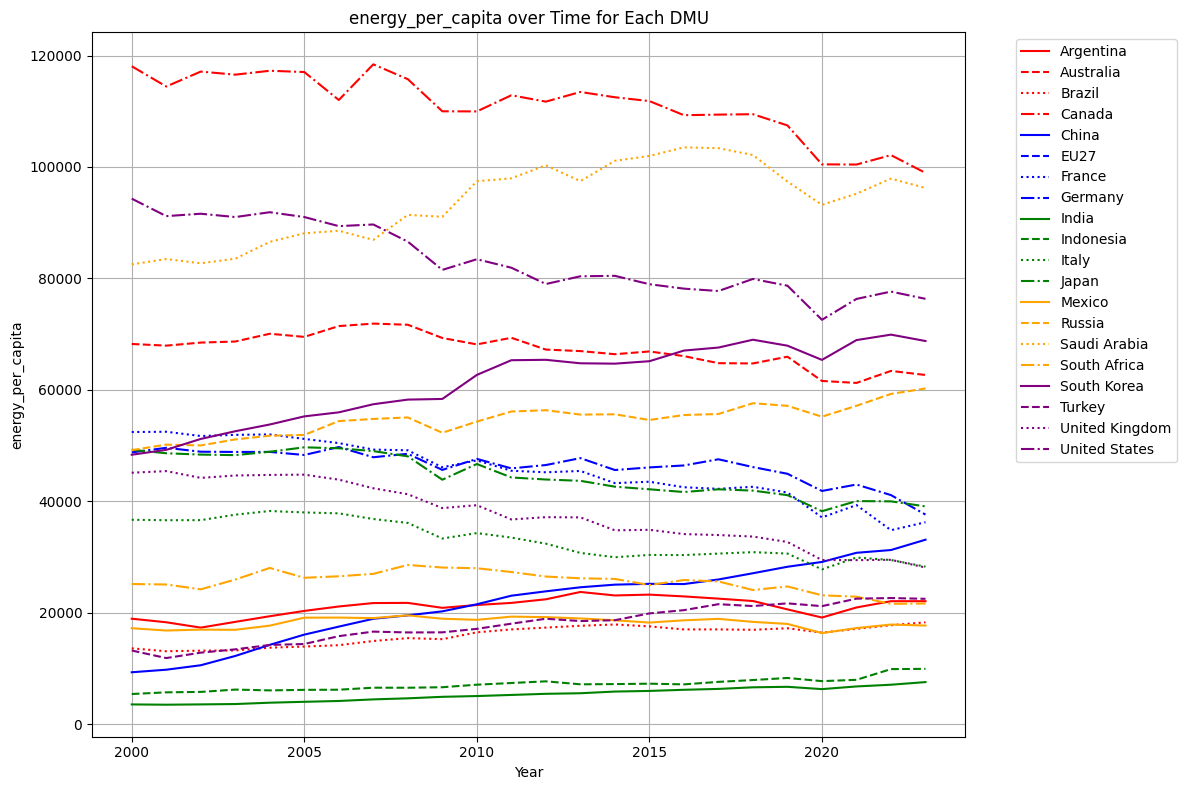

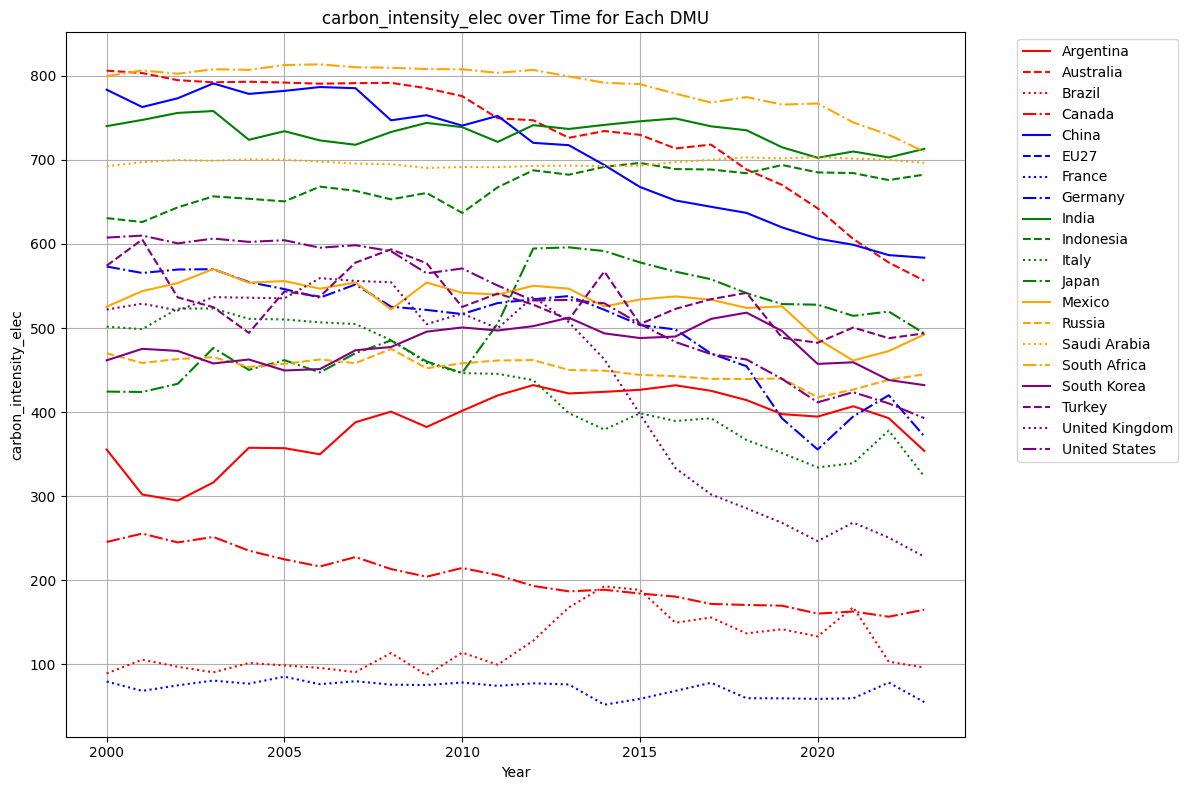

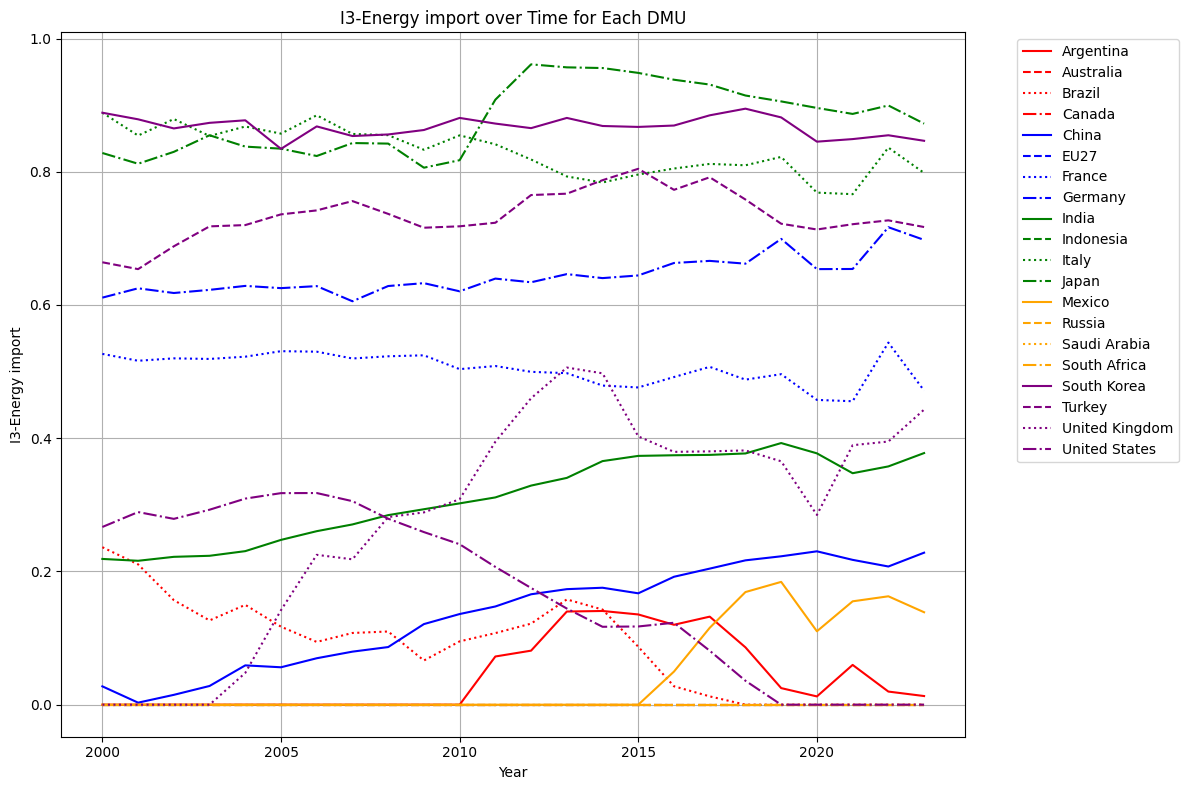

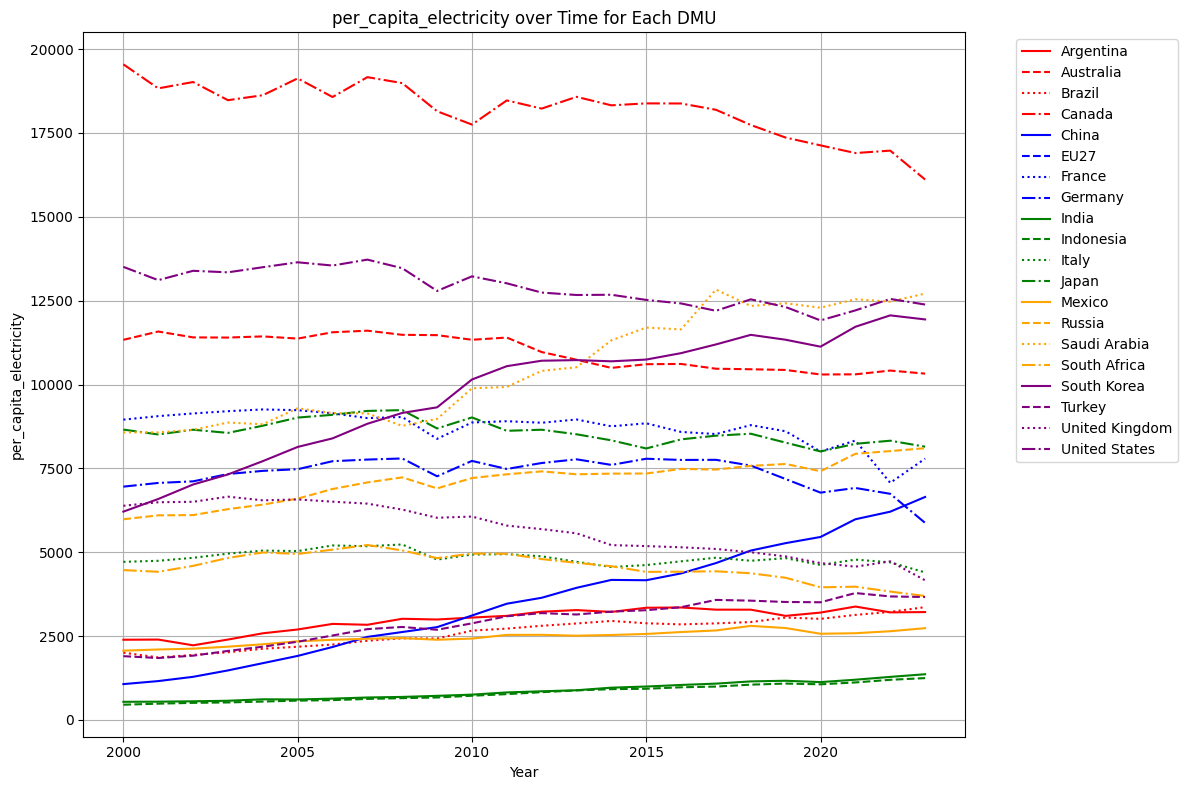

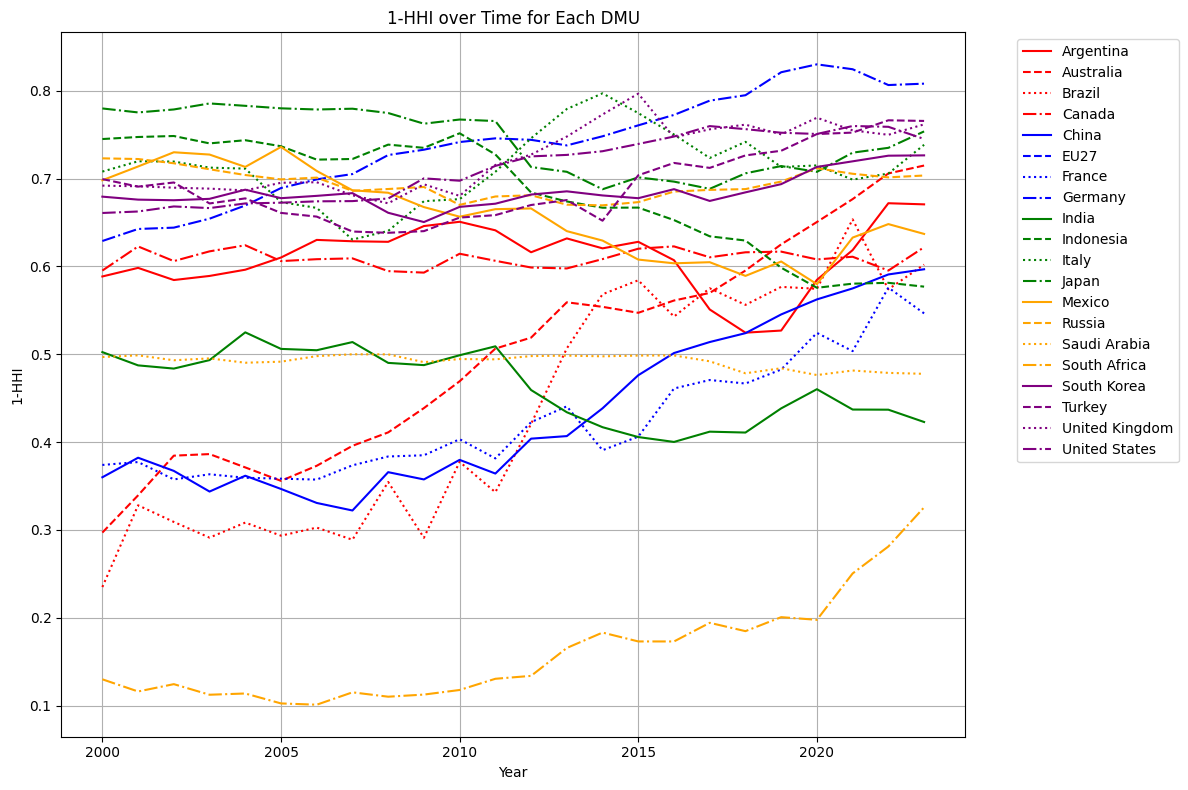

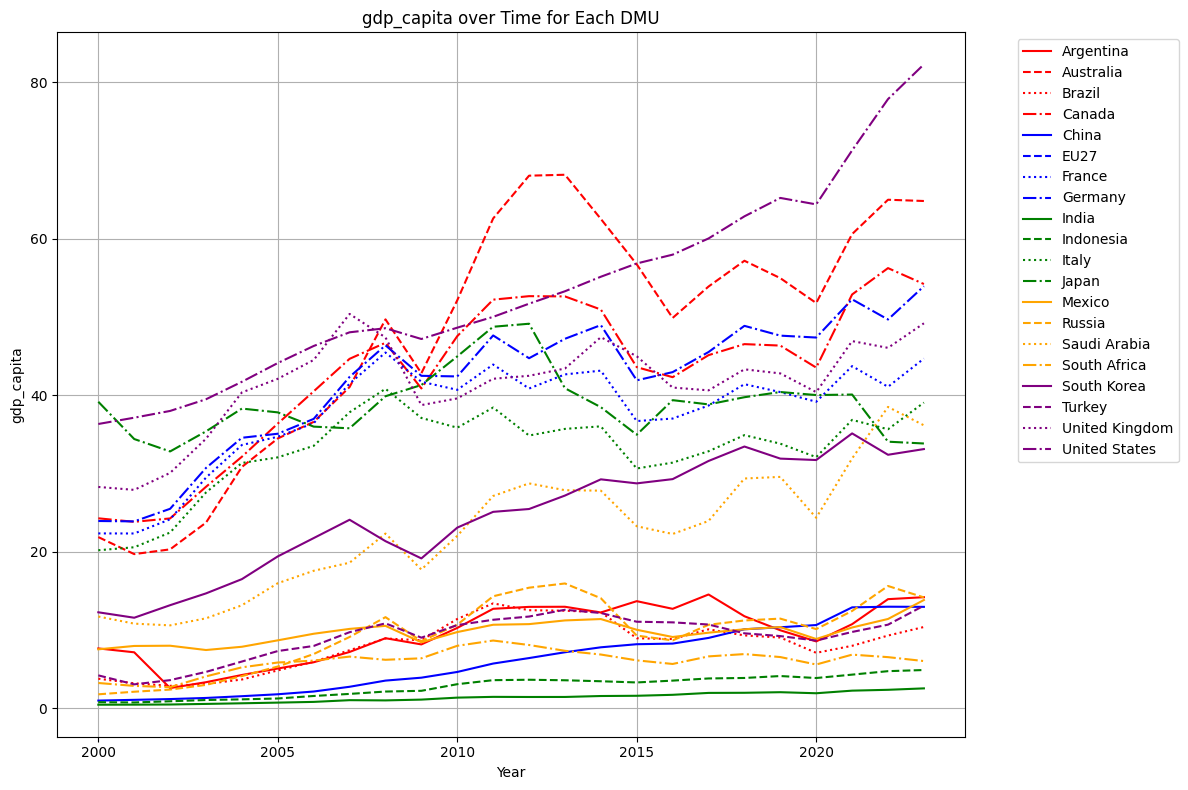

In [ ]:
import itertools

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(countries)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

for variable in variables2plot:
    # Create a cycle of unique (color, style) combinations
    style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)

    plt.figure(figsize=(12, 8))
    for dmu in countries:
      # 'data' will be filtered from 'active_df_for_plotting'
      if old:
        data = df_old[df_old["dmu"] == dmu]
      else:
        data = df_new[df_new["dmu"] == dmu]

      # The variable should already be in 'variables_to_iterate' and checked for existence
      # in 'active_df_for_plotting', so direct access should be safe here.


      color, style = next(style_cycle)
      plt.plot(
            data["year"],
            data[variable],
            label=dmu,
            color=color,
            linestyle = style
        )

    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.title(f"{variable} over Time for Each DMU")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

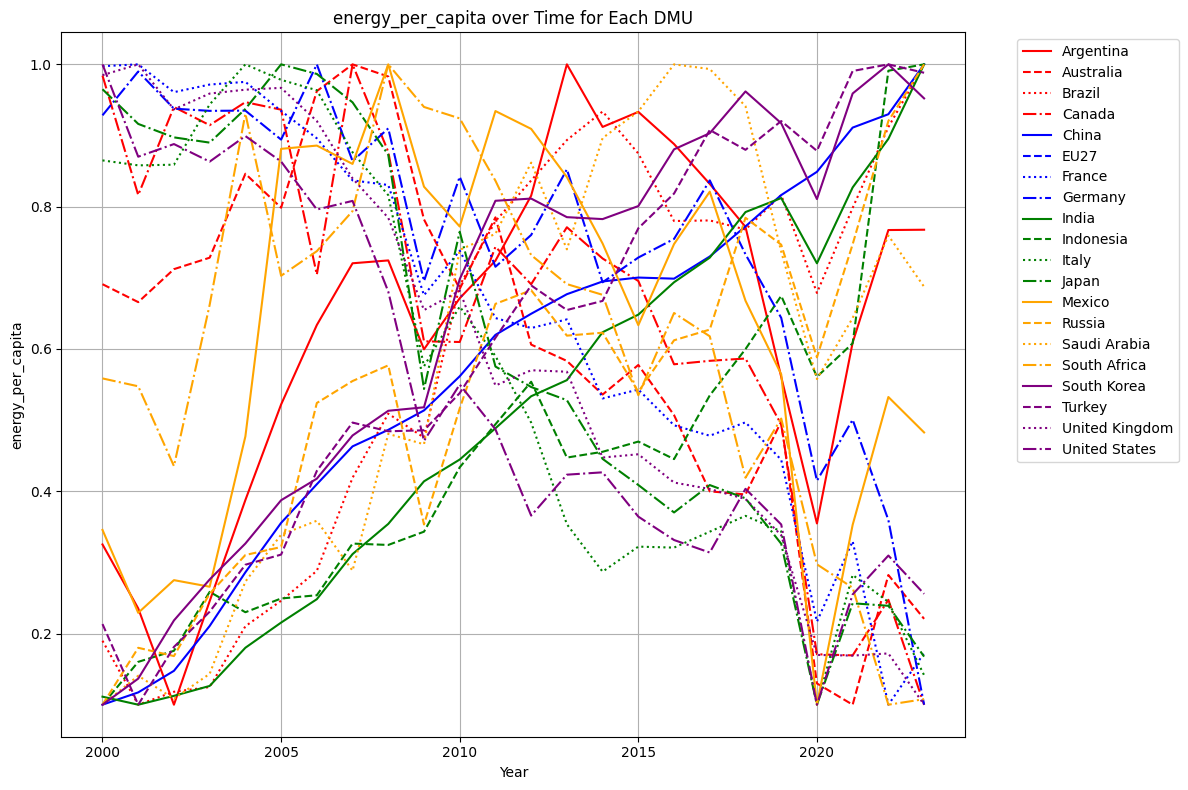

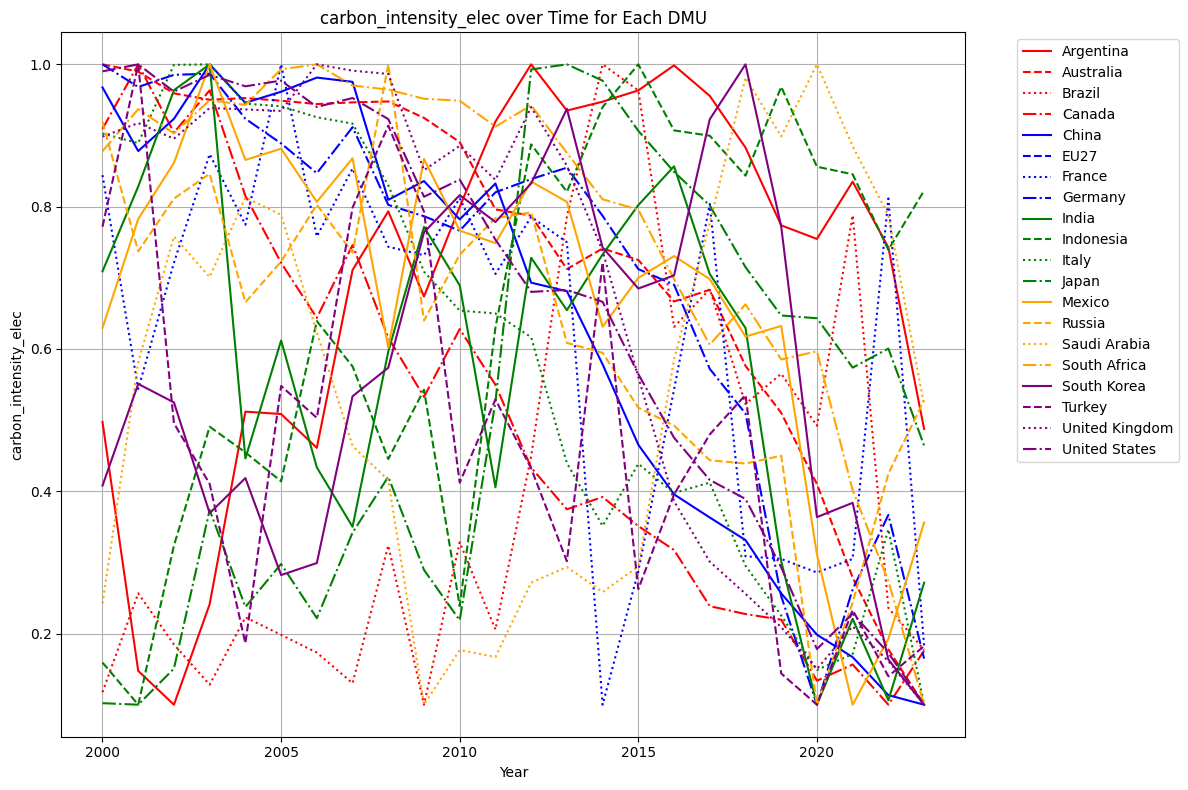

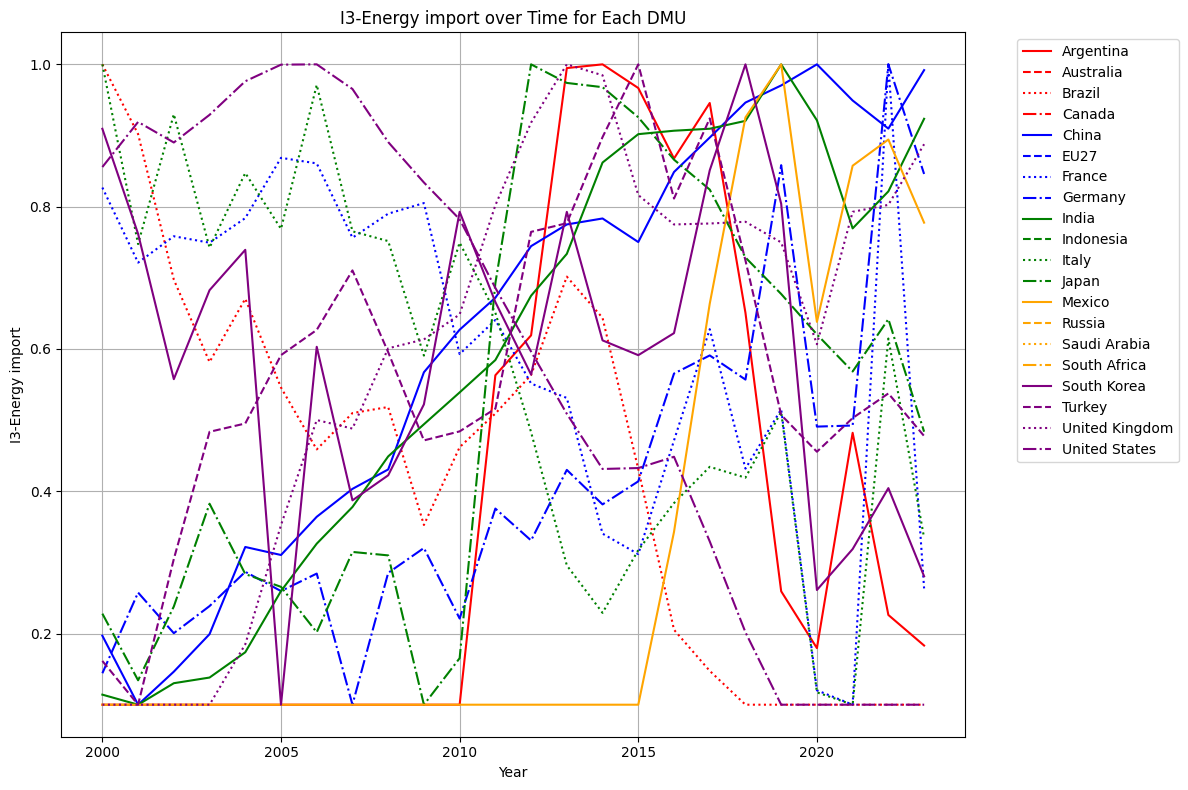

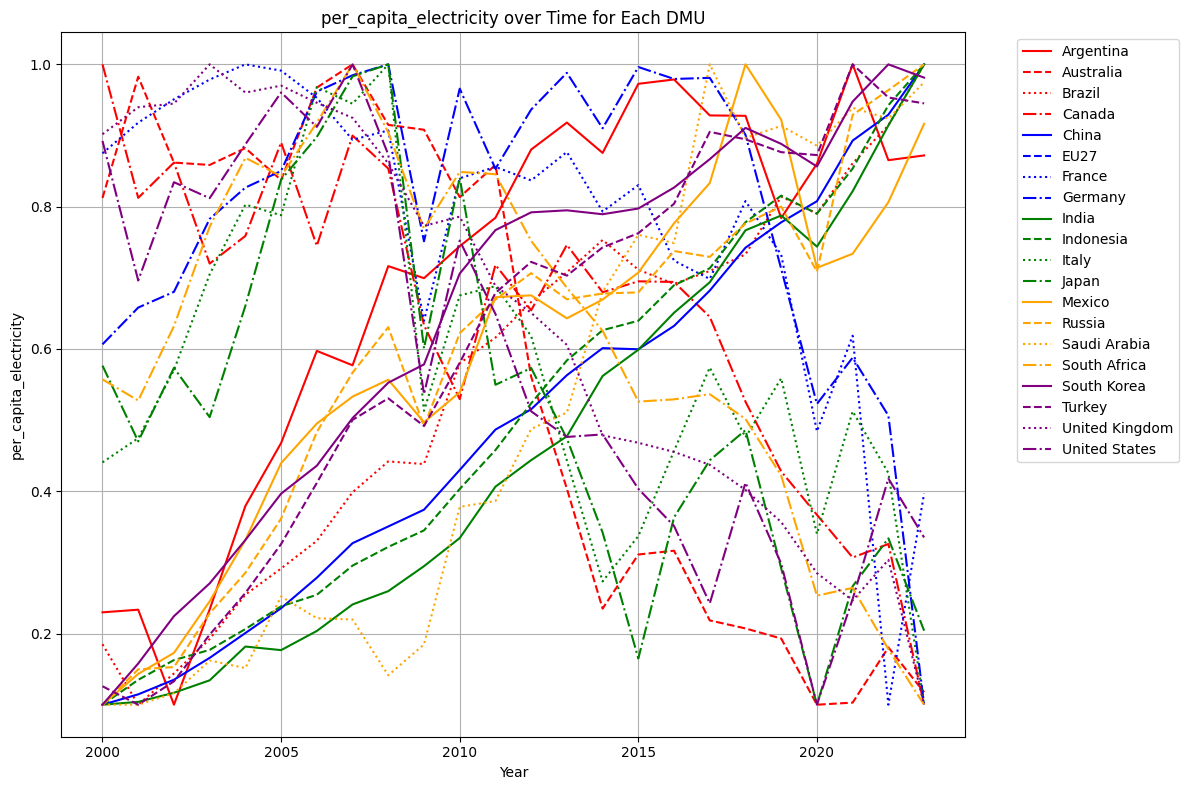

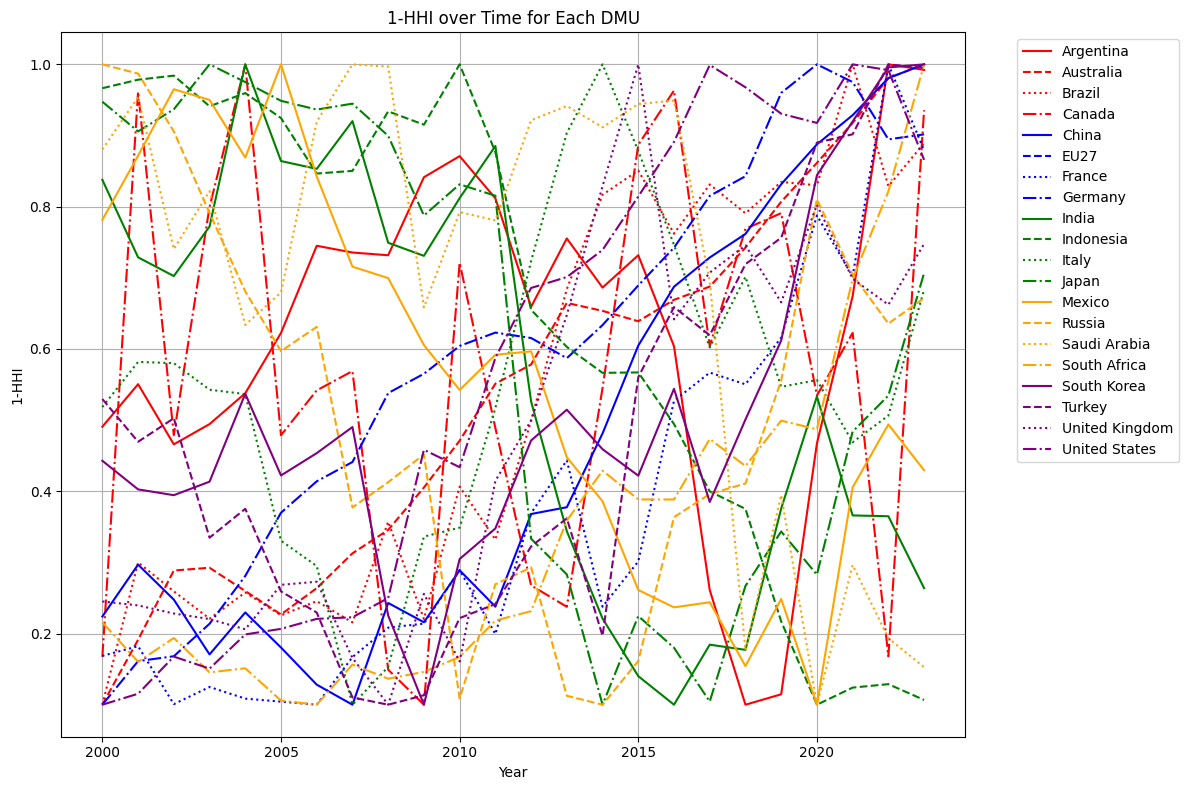

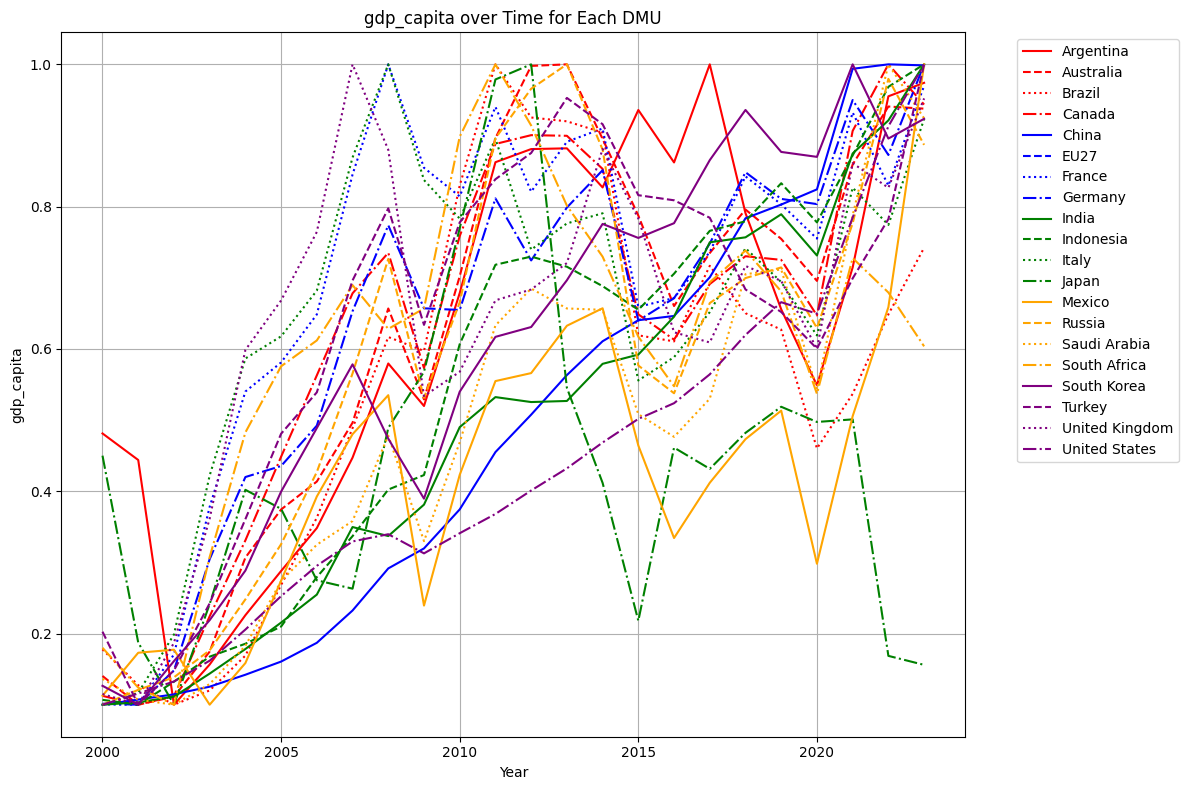

In [ ]:
if normalize == True:

  for variable in variables2plot:
      # Create a cycle of unique (color, style) combinations
      style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)

      plt.figure(figsize=(12, 8))
      for dmu in countries:
        # 'data' will be filtered from 'active_df_for_plotting'
        if old:
          data = df_old[df_old["dmu"] == dmu]
        else:
          data = df_new[df_new["dmu"] == dmu]

        # The variable should already be in 'variables_to_iterate' and checked for existence
        # in 'active_df_for_plotting', so direct access should be safe here.

        color, style = next(style_cycle)
        plt.plot(
              data["year"],
              normalize_data(data[variable]),
              label=dmu,
              color=color,
              linestyle = style
          )

      plt.xlabel("Year")
      plt.ylabel(variable)
      plt.title(f"{variable} over Time for Each DMU")
      plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
      plt.grid(True)
      plt.tight_layout()
      plt.show()

In [ ]:


for year in range(year_start, year_end):
  print("------------\n\n)")
  print ("year:", year)
  print("------------\n\n)")
  if old:
    df_year     = df_old[df_old['year'] == year]
  else:
    df_year     = df_new[df_new['year'] == year]

  inputs_dea = df_year[input_cols]
  outputs_dea = df_year[output_cols]

  print("------------\n\n)")
  print ("Inputs :")
  print("------------\n\n)")
  print (inputs_dea)

  print("------------\n\n")
  print ("Outputs :")
  print("------------\n\n")
  print (outputs_dea)

  if normalize == True:
    for variable in input_cols:
      print ('variable', variable)
      print(inputs_dea[variable])
      inputs_dea[variable] = normalize_data(inputs_dea[variable])

    for variable in output_cols:
      print ('variable', variable)
      print(outputs_dea[variable])
      outputs_dea[variable] = normalize_data(outputs_dea[variable])

    print("------------\n\n")
    print ("Inputs Normalized:")
    print("------------\n\n")
    print (inputs_dea)

    print("------------\n\n")
    print ("Outputs :")
    print("------------\n\n")
    print (outputs_dea)



  prob = DEAProblem(inputs_dea, outputs_dea, returns=method_ret)
  myresults = prob.solve()

  print ('----------------\n\n\n')
  print ('*** Status ***')
  print ('----------------\n\n\n')
  print (myresults['Status'])

  print ('----------------\n\n\n')
  print ('*** Efficiency ***')
  print ('----------------\n\n\n')
  print (myresults['Efficiency'])
  l_results.append(myresults['Efficiency'])
  results[year] = myresults['Efficiency'].values

  print ('----------------\n\n\n')
  print ('----------------\n\n\n')
  print('*** Weights ***')
  print('----------------\n\n\n')

  print (type(myresults['Weights']))
  print (myresults['Weights'])


  print (results[year])
  with pd.ExcelWriter(os.path.join(dir2write,"dea_out_"+ str(year)  + '.xlsx')) as writer:
              inputs_dea.to_excel(writer, sheet_name='Inputs')
              outputs_dea.to_excel(writer, sheet_name='Outputs')
              myresults['Status'].to_excel(writer, sheet_name='Status')
              myresults['Efficiency'].to_excel(writer, sheet_name='Efficiency')
              myresults['Weights'].to_excel(writer, sheet_name='Weights')

  if  os.path.exists(os.path.join(dir2write, "dea_efficiency.xlsx")):
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))
  else:
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='w') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_weights.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='w') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_status.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='w') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))

------------

)
year: 2000
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  I3-Energy import
0            18907.830                355.473          0.000000
24           68222.375                805.977          0.000000
48           13586.250                 89.445          0.236412
72          118073.234                245.686          0.000000
96            9294.628                783.314          0.027547
120          42152.680                419.096          0.671355
144          52416.219                 79.766          0.526597
168          48756.914                573.126          0.611040
192           3521.430                740.037          0.218811
216           5387.870                630.661          0.000000
240          36668.434                501.667          0.888679
264          49228.012                424.427          0.828158
288          17198.160                525.390          0.000000
312          49169.8

/tmp/ipython-input-2323620803.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-2323620803.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



0      Optimal
24     Optimal
48     Optimal
72     Optimal
96     Optimal
120    Optimal
144    Optimal
168    Optimal
192    Optimal
216    Optimal
240    Optimal
264    Optimal
288    Optimal
312    Optimal
336    Optimal
360    Optimal
384    Optimal
408    Optimal
432    Optimal
456    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



0      1.000000
24     1.000000
48     1.000000
72     1.000000
96     0.940779
120    1.000000
144    1.000000
168    0.853809
192    1.000000
216    1.000000
240    0.872044
264    1.000000
288    1.000000
312    1.000000
336    1.000000
360    1.000000
384    0.813646
408    0.989179
432    1.000000
456    1.000000
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  in_I3-Energy import  \
0               

/tmp/ipython-input-2323620803.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-2323620803.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



1      Optimal
25     Optimal
49     Optimal
73     Optimal
97     Optimal
121    Optimal
145    Optimal
169    Optimal
193    Optimal
217    Optimal
241    Optimal
265    Optimal
289    Optimal
313    Optimal
337    Optimal
361    Optimal
385    Optimal
409    Optimal
433    Optimal
457    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



1      1.000000
25     1.000000
49     1.000000
73     1.000000
97     0.969498
121    1.000000
145    1.000000
169    0.853930
193    1.000000
217    1.000000
241    0.892743
265    1.000000
289    1.000000
313    1.000000
337    1.000000
361    1.000000
385    0.809964
409    1.000000
433    1.000000
457    1.000000
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  in_I3-Energy import  \
0               

...

/tmp/ipython-input-2323620803.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-2323620803.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


------------

)
year: 2022
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  I3-Energy import
22           22049.957                392.872          0.019715
46           63386.676                577.862          0.000000
70           17744.197                103.327          0.000000
94          102122.555                156.795          0.000000
118          31235.709                586.700          0.207455
142          35959.199                291.706          0.733434
166          34796.070                 78.550          0.543525
190          41094.148                420.107          0.716746
214           7057.187                702.810          0.357697
238           9859.906                675.931          0.000000
262          29444.693                378.163          0.836290
286          39974.961                519.619          0.899503
310          17858.705                472.586          0.162731
334          59257.9

/tmp/ipython-input-2323620803.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-2323620803.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


------------

)
year: 2023
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  I3-Energy import
23           22053.076                353.958          0.013000
47           62658.199                556.296          0.000000
71           18252.031                 96.396          0.000000
95           98930.125                165.148          0.000000
119          33089.070                583.608          0.228201
143          34828.594                237.487          0.677713
167          36221.523                 55.275          0.471513
191          37598.512                371.311          0.697717
215           7529.441                713.013          0.377728
239           9904.814                682.430          0.000000
263          28246.574                323.448          0.798216
287          39064.852                493.585          0.872238
311          17682.668                492.335          0.138795
335          60237.0

/tmp/ipython-input-2323620803.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-2323620803.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


# New Section

In [ ]:
results.head(20)
results.to_excel(os.path.join(dir2write,"dea_results.xlsx"))

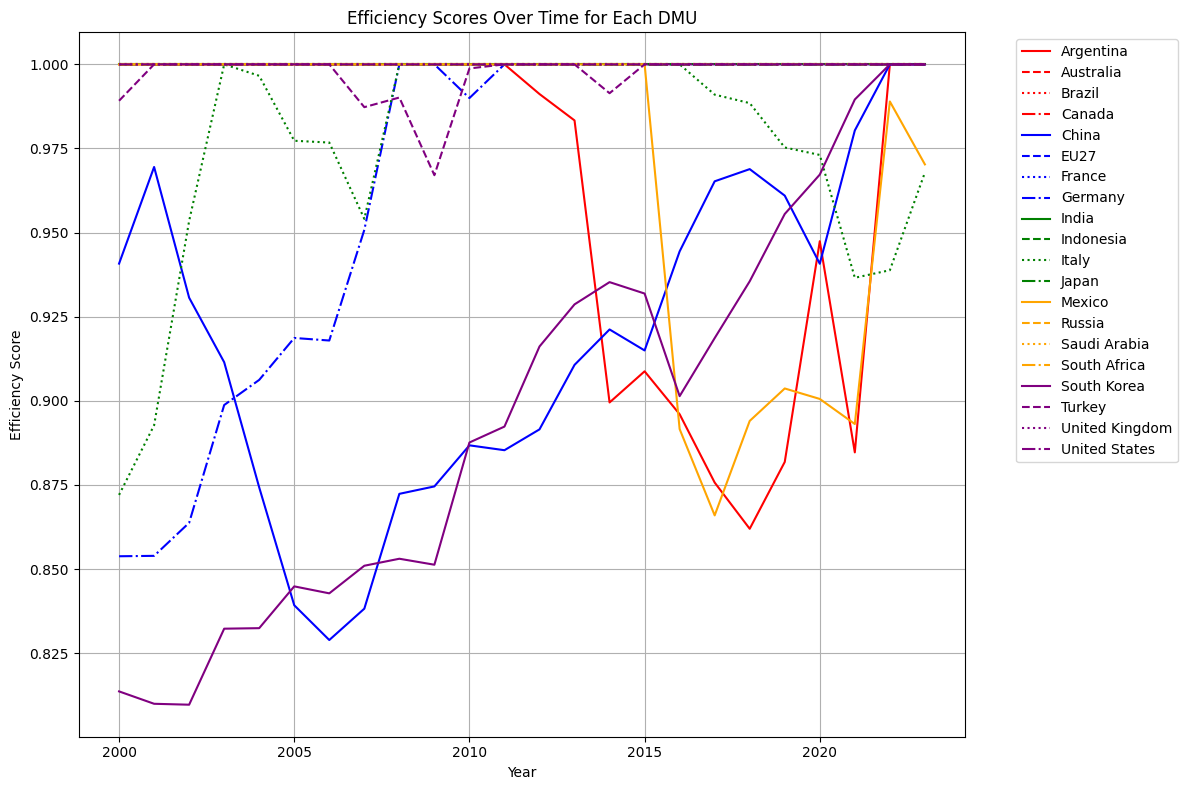

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import matplotlib.pyplot as plt

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(results)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)


# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)
plt.figure(figsize=(12, 8))
for (index, row) in results.iterrows():
    color, style = next(style_cycle)
    dmu = row['DMU']
    efficiencies = row[results.columns[1:]].values
    years = results.columns[1:]  # Exclude 'DMU' column
    #print(years)
    #print (efficiencies)
    plt.plot(years, efficiencies, label=dmu, color=color, linestyle=style)

plt.xlabel('Year')
plt.ylabel('Efficiency Score')
plt.title('Efficiency Scores Over Time for Each DMU')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(datetime.now())

2026-01-24 21:46:55.789366


year 2000
results[year]
0      1.000000
25     1.000000
50     1.000000
75     1.000000
100    0.940779
125    1.000000
150    1.000000
175    0.853809
200    1.000000
225    1.000000
250    0.872044
275    1.000000
300    1.000000
325    1.000000
350    1.000000
375    1.000000
400    0.813646
425    0.989179
450    1.000000
475    1.000000
Name: 2000, dtype: float64
range
range(0, 20)
results[DMU]
0           Argentina
25          Australia
50             Brazil
75             Canada
100             China
125              EU27
150            France
175           Germany
200             India
225         Indonesia
250             Italy
275             Japan
300            Mexico
325            Russia
350      Saudi Arabia
375      South Africa
400       South Korea
425            Turkey
450    United Kingdom
475     United States
Name: DMU, dtype: object
year 2001
results[year]
0      1.000000
25     1.000000
50     1.000000
75     1.000000
100    0.969498
125    1.000000
150    1.000

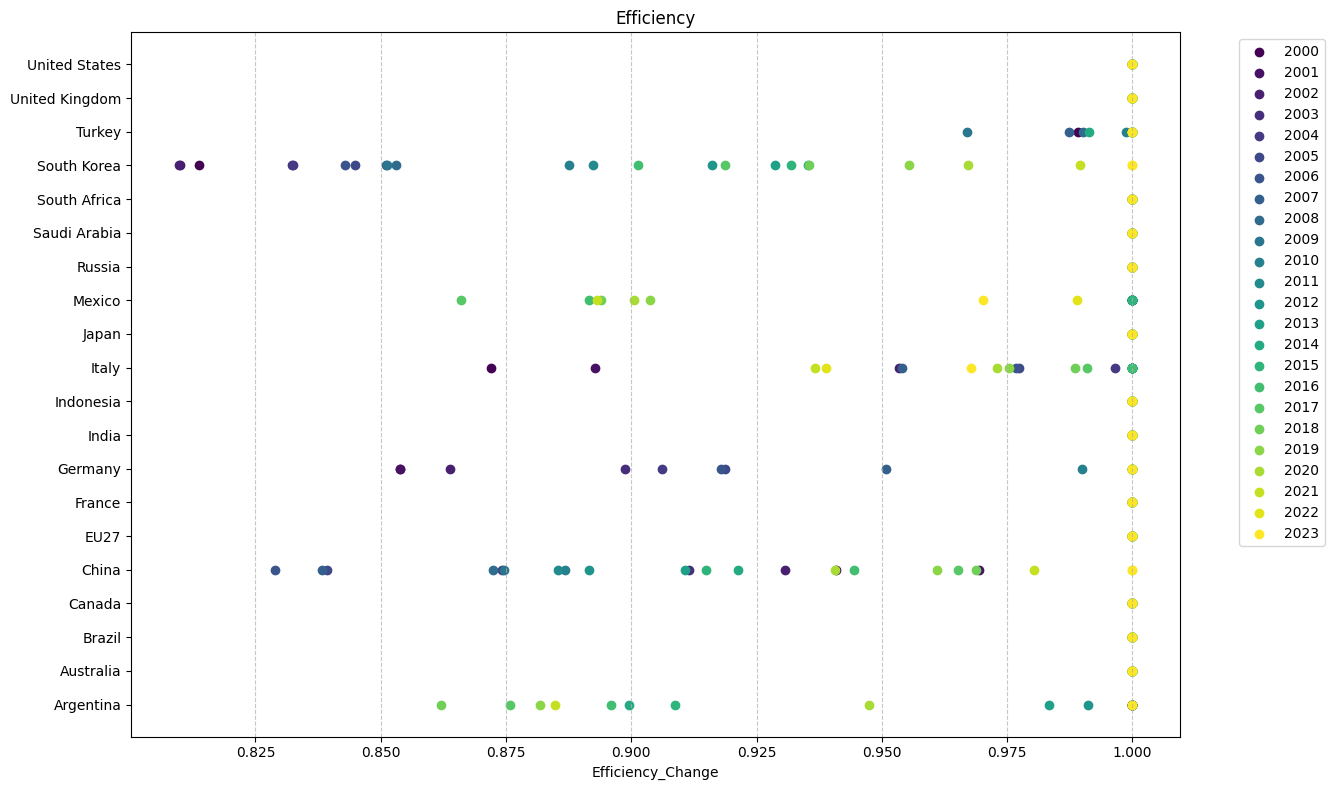

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
years = list(range(year_start, year_end))
cmap = plt.cm.viridis
norm = plt.Normalize(min(years), max(years))

for year in range(year_start,year_end):

  print ("year", year)
  # Create the figure and ax  is

  # Plot the mean EC points
  print("results[year]")
  print (results[year])
  print("range")
  print(range(len(results)))

  print ("results[DMU]")
  print (results['DMU'])

  ax.scatter(results[year], range(len(results)), label=str(year), color=cmap(norm(year)))

  # Plot the confidence intervals
  #for idx, row in df4.iterrows():
  #    ax.hlines(y=df4.index.get_loc(idx),
  #              xmin=row['Eff_CI_Lower'],
  #              xmax=row['Eff_CI_Upper'],
  #              color='blue',
  #              alpha=0.3)

#Customize the plot
ax.set_yticks(range(len(results)))
ax.set_yticklabels(results['DMU'])
ax.set_xlabel('Efficiency_Change')
ax.set_title('Efficiency')

# Add a grid for better readability
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
# In order to get automatic or manual limits in X-axis
#ax.set_xlim(0,1)
# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(dir2write,"efficiency_plot.png"))
plt.show()